# Incremental wNum Learning + Feature Ablation

This notebook combines the **curriculum wNum training** from `incremental_learning.ipynb`
with the **feature ablation study** from `orchestrator_ablation.ipynb`.

## Key Question

**Does feature importance change as you include harder (lower-wNum) nodes?**

At each wNum curriculum level, we run progressive feature addition and
leave-one-group-out ablation using a single probe model (`graphsage` / `ce`),
then compare feature importance rankings across levels via Spearman correlation.

## Pipeline

1. Discover wNum range and max `num_classes`
2. Build ablation configs (progressive + drop-one-out + determined)
3. For each wNum level: load graph, build frontier mask, run all ablation configs
4. Aggregate into a 2D (wNum x feature_set) results table
5. Heatmap visualization + Spearman rank correlation of feature importance
6. Cross-pipeline comparison with saved orchestrator/incremental results


In [1]:
# Force reload of graph_label_prediction modules to pick up code changes
import importlib
import sys

modules_to_reload = [m for m in sys.modules.keys() if m.startswith('graph_label_prediction')]
for module in modules_to_reload:
    del sys.modules[module]

print(f"Cleared {len(modules_to_reload)} cached modules")

Cleared 0 cached modules


## 1. Imports

In [2]:
import os
import json
import sys
from pathlib import Path
from datetime import datetime

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from scipy.stats import spearmanr, pearsonr

# Add parent directory to path for pipeline modules
ml_path = Path('.').absolute().parent.parent
if str(ml_path) not in sys.path:
    sys.path.insert(0, str(ml_path))

neo4j_path = ml_path / 'neo4j'
if str(neo4j_path) not in sys.path:
    sys.path.insert(0, str(neo4j_path))

from neo4jClient import Neo4jClient

from graph_label_prediction.python_model.core.data_loader import GraphDataLoader
from graph_label_prediction.python_model.core.config import (
    WNUM_DISCOVERY_QUERY,
    SPECTRAL_PE_DIM,
    NUM_BASE_FEATURES,
)
from graph_label_prediction.python_model.core.experiment import (
    ExperimentConfig, ExperimentRunner, ExperimentReport,
)
from graph_label_prediction.python_model.features.feature_sets import (
    FEATURE_SETS, node_feature_indices,
)
from graph_label_prediction.python_model.features.edge_feature_sets import (
    EDGE_FEATURE_SETS, edge_feature_indices,
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Feature sets: {list(FEATURE_SETS.keys())}")
print("Imports successful")

PyTorch version: 2.9.1+cpu
CUDA available: False
Feature sets: ['core_only', 'core_coeff', 'core_coeff_stats', 'all_no_spectral', 'full', 'drop_spectral', 'drop_set_union', 'drop_statistical', 'drop_coefficient', 'full_no_determined']
Imports successful


## 2. Load Environment and Connect to Neo4j

In [3]:
# Load environment variables from .env file
env_paths = [Path('.env'), Path('../.env'), Path('../../.env')]

for env_path in env_paths:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f"Loaded .env from: {env_path.absolute()}")
        break

NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

print(f"\nConnection Configuration:")
print(f"  URI: {NEO4J_URI}")
print(f"  User: {NEO4J_USER}")
print(f"  Password: {'*' * len(NEO4J_PASSWORD) if NEO4J_PASSWORD else 'NOT SET'}")
print(f"  Database: {NEO4J_DATABASE}")

Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\..\..\.env

Connection Configuration:
  URI: bolt://localhost:7687
  User: neo4j
  Password: ***********
  Database: d5seed1


In [4]:
try:
    client = Neo4jClient(
        uri=NEO4J_URI,
        user=NEO4J_USER,
        password=NEO4J_PASSWORD
    )
    print("Neo4j client initialized successfully")

    test_query = "MATCH (n:Dnode) RETURN count(n) AS total_nodes"
    result = client.run_query(test_query, NEO4J_DATABASE)
    print(f"Database contains {result['total_nodes'].iloc[0]:,} Dnode nodes")

except ConnectionError as e:
    print(f"Connection failed: {e}")
    raise

Neo4j client initialized successfully
Database contains 3,024,769 Dnode nodes


## 3. Discover wNum Range

In [5]:
# Discover distinct wNum values and their node counts
wnum_df = client.run_query(WNUM_DISCOVERY_QUERY, NEO4J_DATABASE)

print("wNum distribution in graph (pArrayList in [-10, 10)):")
print(wnum_df.to_string(index=False))

wnum_values = sorted(wnum_df['wNum'].tolist())
wnum_max = max(wnum_values)
wnum_min = min(wnum_values)

print(f"\nwNum range: [{wnum_min}, {wnum_max}]")
print(f"Distinct wNum levels: {len(wnum_values)}")

wNum distribution in graph (pArrayList in [-10, 10)):
 wNum  nodeCount
    5          1
    4         20
    3        185
    2       1647
    1      14471
    0     128072

wNum range: [0, 5]
Distinct wNum levels: 6


## 4. Discover Max Classes and Define Ablation Configs

Pre-allocate all models with `max_num_classes` for consistent output head size.
Use a single probe model for the ablation axis to keep run count manageable.

In [6]:
# Discover max num_classes from the full graph (wNum >= 0)
print("Loading full graph (wNum >= 0) to discover max num_classes...")
full_loader = GraphDataLoader(client, NEO4J_DATABASE, min_wnum=0)
full_data = full_loader.load()
max_num_classes = full_data.num_classes
del full_data, full_loader
print(f"Global max_num_classes = {max_num_classes}\n")

# Probe model configuration
PROBE_MODEL = 'graphsage'
PROBE_LOSS = 'ce'
LR_DECAY = 0.5

# =====================================================================
# Progressive addition: core_only -> ... -> full
# =====================================================================
progressive_sets = [
    'core_only',
    'core_coeff',
    'core_coeff_stats',
    'all_no_spectral',
    'full',
]

progressive_configs = [
    ExperimentConfig(
        name=f"{PROBE_MODEL}-{fs}",
        model_name=PROBE_MODEL,
        loss_type=PROBE_LOSS,
        feature_set=fs,
        edge_feature_set='full',
        model_kwargs={'num_classes': max_num_classes},
    )
    for fs in progressive_sets
]

# =====================================================================
# Leave-one-group-out
# =====================================================================
drop_sets = [fs for fs in FEATURE_SETS if fs.startswith('drop_')]

drop_configs = [
    ExperimentConfig(
        name=f"{PROBE_MODEL}-{fs}",
        model_name=PROBE_MODEL,
        loss_type=PROBE_LOSS,
        feature_set=fs,
        edge_feature_set='full',
        model_kwargs={'num_classes': max_num_classes},
    )
    for fs in drop_sets
]

# =====================================================================
# Determined ablation
# =====================================================================
determined_configs = [
    ExperimentConfig(
        name=f"{PROBE_MODEL}-full_no_determined",
        model_name=PROBE_MODEL,
        loss_type=PROBE_LOSS,
        feature_set='full_no_determined',
        edge_feature_set='full',
        model_kwargs={'num_classes': max_num_classes},
    ),
]

# Combine and deduplicate (progressive already includes 'full')
all_ablation_configs = progressive_configs + drop_configs + determined_configs
seen_names = set()
deduped_configs = []
for cfg in all_ablation_configs:
    if cfg.name not in seen_names:
        deduped_configs.append(cfg)
        seen_names.add(cfg.name)
all_ablation_configs = deduped_configs

print(f"Probe model: {PROBE_MODEL} / {PROBE_LOSS}")
print(f"LR decay per level: {LR_DECAY}")
print(f"\nAblation configs ({len(all_ablation_configs)} unique):")
for cfg in all_ablation_configs:
    n_feat = len(node_feature_indices(cfg.feature_set))
    print(f"  {cfg.name:<35} feature_set={cfg.feature_set:<22} ({n_feat}D)")

Loading full graph (wNum >= 0) to discover max num_classes...
Using incremental queries (wNum >= 0)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH dd AS d, cb.wNum AS wNum LIMIT 1

Label mapping: 6 classes present [0, 1, 2, 3, 4, 5] -> [0..5]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Graph has 144,396 nodes (>100,000)
Skipping spectral PE computation (requires too much memory)
Using only base features as input (dim=3)
Global max_num_classes = 6

Probe model: graphsage / ce
LR decay per level: 0.5

Ablation configs (10 unique):
  graphsage-core_only                 feature_set=core_only              (3D)
  graphsage-core_coeff                feature_set=core_coeff             (9D)
  graphsage-core_coeff_stats          feature_set=core_coeff_stats       (14D)
  graphsage-all_no_spectral           feature_set=all_no_spectral        (17D)
  graphsage-full                      feature_set=full                   (25D)
  graphsage-drop_spectral             feature_set=drop_spectral          (17D)
  graphsage-drop_set_union            feature_set=drop_set_union         (22D)
  graphsage-drop_statistical          feature_set=drop_statistical       (20D)
  graphsage-drop_coefficient          feature_set=drop_coefficient       (19D)
  graphsage-full_no_determined        featu

## 5. Curriculum Ablation Loop

For each `min_wnum` from `wNum_max` down to `wNum_min`:
1. Load graph, build frontier mask
2. Run all ablation configs (progressive + drop + determined)
3. Collect results annotated with `min_wnum`

No checkpoints are carried between levels -- each level trains from scratch.
The goal is measuring relative feature importance at each depth, not absolute
performance. See `curriculum_model_feature_sweep.ipynb` for the full curriculum version.

In [7]:
ablation_results = []  # List[Dict] with keys: min_wnum, num_nodes, num_edges, num_classes, report
level_idx = 0

for min_wnum in range(wnum_max, wnum_min - 1, -1):
    print(f"\n{'#' * 80}")
    print(f"# ABLATION LEVEL: min_wnum = {min_wnum}  (level {level_idx})")
    print(f"{'#' * 80}")

    # 1. Load graph at this wNum threshold
    loader = GraphDataLoader(client, NEO4J_DATABASE, min_wnum=min_wnum)
    try:
        data = loader.load()
    except ValueError as e:
        print(f"  Skipping min_wnum={min_wnum}: {e}")
        continue

    stats = loader.get_graph_stats(data)
    print(f"  Nodes: {stats['num_nodes']:,}  |  Edges: {stats['num_edges']:,}  |  Classes: {data.num_classes}")
    print(f"  Class distribution: {stats['class_distribution']}")

    # Skip if insufficient nodes/edges for training
    min_class_count = min(stats['class_distribution'].values()) if stats['class_distribution'] else 0
    if stats['num_edges'] == 0:
        print(f"  Skipping min_wnum={min_wnum}: no edges (isolated node(s))")
        continue
    if data.num_nodes < 10 or min_class_count < 2:
        print(f"  Skipping min_wnum={min_wnum}: too few nodes ({data.num_nodes}) or min class count ({min_class_count}) < 2")
        continue

    # 2. Build frontier mask
    if level_idx == 0:
        frontier_mask = None
    else:
        frontier_mask = (data.wNum == min_wnum)
        n_frontier = frontier_mask.sum().item()
        n_total = data.num_nodes
        print(f"  Frontier nodes (wNum={min_wnum}): {n_frontier} / {n_total} ({100*n_frontier/n_total:.1f}%)")

    # 3. Build level-specific configs with decayed LR
    current_lr_scale = LR_DECAY ** level_idx
    level_configs = [
        ExperimentConfig(
            name=cfg.name,
            model_name=cfg.model_name,
            loss_type=cfg.loss_type,
            activation=cfg.activation,
            weight_decay=cfg.weight_decay,
            learning_rate=cfg.learning_rate * current_lr_scale,
            hidden_dim=cfg.hidden_dim,
            dropout=cfg.dropout,
            max_epochs=cfg.max_epochs,
            patience=cfg.patience,
            feature_set=cfg.feature_set,
            edge_feature_set=cfg.edge_feature_set,
            model_kwargs=cfg.model_kwargs.copy(),
        )
        for cfg in all_ablation_configs
    ]
    print(f"  LR scale: {current_lr_scale:.4f}  |  Configs: {len(level_configs)}")

    # 4. Run all ablation configs (with frontier supervision, no checkpoints)
    runner = ExperimentRunner(data, trainer_kwargs={'use_class_weights': True})
    report = runner.run_all(level_configs, verbose=False, frontier_mask=frontier_mask)

    # Print quick summary
    best = report.best()
    if best:
        print(f"  Best: {best['name']}  Macro F1={best.get('test_macro_f1', 0):.4f}")

    # 5. Store results
    ablation_results.append({
        'min_wnum': min_wnum,
        'num_nodes': stats['num_nodes'],
        'num_edges': stats['num_edges'],
        'num_classes': data.num_classes,
        'class_distribution': stats['class_distribution'],
        'report': report,
    })
    level_idx += 1

print(f"\n{'=' * 80}")
print(f"Completed {len(ablation_results)} ablation levels")
print(f"{'=' * 80}")


################################################################################
# ABLATION LEVEL: min_wnum = 5  (level 0)
################################################################################
Using incremental queries (wNum >= 5)...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 5))\n     WITH dd AS d, cb.wNum AS wNum LIMIT 1

Label mapping: 1 classes present [0] -> [0..0]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 5))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Computing spectral positional encodings for 1 nodes...
  Feature dim: 25 (17 base+coeff+stats+set_union + 8 spectral PE)
  Nodes: 1  |  Edges: 0  |  Classes: 1
  Class distribution: {0: 1}
  Skipping min_wnum=5: no edges (isolated node(s))

################################################################################
# ABLATION LEVEL: min_wnum = 4  (level 0)
################################################################################
Using incremental queries (wNum >= 4)...


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)\n     WHERE ( all(x IN cb.pArrayList WHERE x >= -10 AND x < 10 ) AND (cb.wNum >= 0))\n     WITH DISTINCT d AS unique_D\n     RETURN uniqu

Graph has 144,396 nodes (>100,000)
Skipping spectral PE computation (requires too much memory)
Using only base features as input (dim=3)
  Nodes: 144,396  |  Edges: 144,395  |  Classes: 6
  Class distribution: {0: 3, 1: 122317, 2: 18484, 3: 2801, 4: 368, 5: 423}
  Frontier nodes (wNum=0): 128072 / 144396 (88.7%)
  LR scale: 0.1250  |  Configs: 10
  Restoring checkpoints from previous level (10 configs)
Stratified split (guaranteed class coverage):
  Train: 93858 | Val: 21659 | Test: 28879
  Train classes: [0, 1, 2, 3, 4, 5]
  Val classes: [0, 1, 2, 3, 4, 5]
  Test classes: [0, 1, 2, 3, 4, 5]
Class weights (sqrt inverse frequency, normalized):
  0 roots: 5.163
  1 root: 0.018
  2 roots: 0.047
  3 roots: 0.121
  4 roots: 0.339
  5 roots: 0.312


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  

  Best: graphsage-core_only  Macro F1=0.4804

Completed 4 ablation levels


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 6. Aggregate Metrics

Build a single DataFrame with one row per (min_wnum, feature_set) combination.

In [8]:
rows = []
for entry in ablation_results:
    min_wnum = entry['min_wnum']
    num_nodes = entry['num_nodes']
    num_edges = entry['num_edges']
    num_classes = entry['num_classes']
    report = entry['report']

    for cfg, metrics in zip(report.configs, report.results):
        n_feat = len(node_feature_indices(cfg.feature_set))
        rows.append({
            'min_wnum': min_wnum,
            'feature_set': cfg.feature_set,
            'model_name': cfg.name,
            'num_nodes': num_nodes,
            'num_edges': num_edges,
            'num_classes': num_classes,
            'num_node_features': n_feat,
            'test_macro_f1': metrics.get('test_macro_f1', float('nan')),
            'test_balanced_acc': metrics.get('test_balanced_acc', float('nan')),
            'test_mae': metrics.get('test_mae', float('nan')),
            'val_macro_f1': metrics.get('val_macro_f1', float('nan')),
            'epochs_trained': metrics.get('epochs_trained', 0),
        })

agg_df = pd.DataFrame(rows)

print(f"Aggregated {len(agg_df)} rows "
      f"({len(agg_df['feature_set'].unique())} feature sets x "
      f"{len(agg_df['min_wnum'].unique())} wNum levels)")
print()

# Display the full table
display_df = agg_df.sort_values(['min_wnum', 'feature_set'], ascending=[False, True])
display_cols = ['min_wnum', 'feature_set', 'num_node_features', 'num_nodes',
                'test_macro_f1', 'test_balanced_acc', 'test_mae', 'epochs_trained']
display_df[[c for c in display_cols if c in display_df.columns]]

Aggregated 40 rows (10 feature sets x 4 wNum levels)



,min_wnum,feature_set,num_node_features,num_nodes,test_macro_f1,test_balanced_acc,test_mae,epochs_trained
3,3,all_no_spectral,17,206,0.822917,0.979798,0.097561,100
1,3,core_coeff,9,206,0.883761,0.989899,0.048780,100
2,3,core_coeff_stats,14,206,0.756272,0.959596,0.195122,100
0,3,core_only,3,206,1.000000,1.000000,0.000000,100
8,3,drop_coefficient,19,206,0.784127,0.969697,0.146341,100
6,3,drop_set_union,22,206,0.822917,0.979798,0.097561,100
5,3,drop_spectral,17,206,0.883761,0.989899,0.048780,100
7,3,drop_statistical,20,206,0.883761,0.989899,0.048780,100
4,3,full,25,206,0.822917,0.979798,0.097561,100
9,3,full_no_determined,24,206,0.822917,0.979798,0.097561,100


## 7. Heatmap: Feature Set x wNum Level

Rows = feature sets, columns = min_wnum levels, values = Test Macro F1.
Separate panels for progressive addition and leave-one-out.

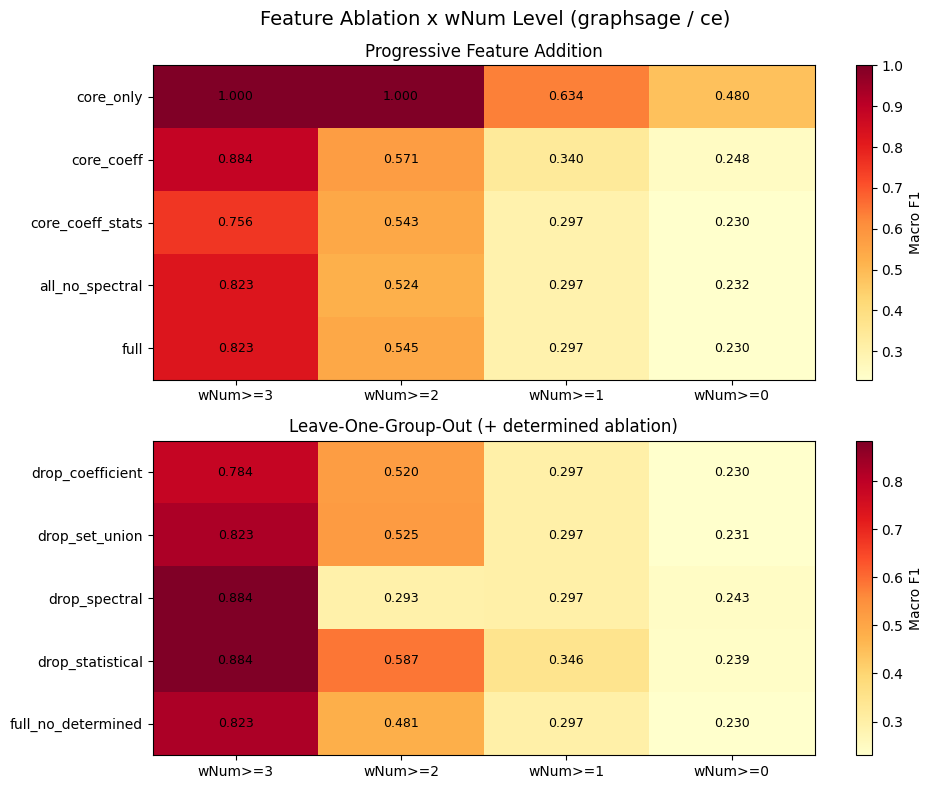

In [9]:
# Pivot to 2D: rows=feature_set, columns=min_wnum
pivot_df = agg_df.pivot_table(
    index='feature_set', columns='min_wnum', values='test_macro_f1'
).sort_index(axis=1, ascending=False)  # high wNum on left

# Split into progressive and drop sets
prog_order = ['core_only', 'core_coeff', 'core_coeff_stats', 'all_no_spectral', 'full']
drop_order = sorted([fs for fs in pivot_df.index if fs.startswith('drop_')]) + ['full_no_determined']
drop_order = [fs for fs in drop_order if fs in pivot_df.index]

prog_pivot = pivot_df.loc[[fs for fs in prog_order if fs in pivot_df.index]]
drop_pivot = pivot_df.loc[[fs for fs in drop_order if fs in pivot_df.index]]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Progressive addition heatmap
ax = axes[0]
im = ax.imshow(prog_pivot.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(prog_pivot.columns)))
ax.set_xticklabels([f"wNum>={c}" for c in prog_pivot.columns])
ax.set_yticks(range(len(prog_pivot.index)))
ax.set_yticklabels(prog_pivot.index)
ax.set_title('Progressive Feature Addition')
for i in range(len(prog_pivot.index)):
    for j in range(len(prog_pivot.columns)):
        val = prog_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Macro F1')

# Drop-one-out heatmap
if len(drop_pivot) > 0:
    ax = axes[1]
    im2 = ax.imshow(drop_pivot.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(drop_pivot.columns)))
    ax.set_xticklabels([f"wNum>={c}" for c in drop_pivot.columns])
    ax.set_yticks(range(len(drop_pivot.index)))
    ax.set_yticklabels(drop_pivot.index)
    ax.set_title('Leave-One-Group-Out (+ determined ablation)')
    for i in range(len(drop_pivot.index)):
        for j in range(len(drop_pivot.columns)):
            val = drop_pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=9)
    plt.colorbar(im2, ax=ax, label='Macro F1')

fig.suptitle(f'Feature Ablation x wNum Level ({PROBE_MODEL} / {PROBE_LOSS})', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Feature Importance Ranking + Spearman Correlation

For each wNum level, compute feature importance as `F1(full) - F1(drop_X)`.
Then correlate importance rankings across levels to see if feature importance
is stable or shifts with difficulty.

In [10]:
# Compute feature importance: F1(full) - F1(drop_X) per level
levels = sorted(agg_df['min_wnum'].unique(), reverse=True)
drop_features = sorted([fs for fs in agg_df['feature_set'].unique() if fs.startswith('drop_')])

# Also include full_no_determined if present
if 'full_no_determined' in agg_df['feature_set'].unique():
    drop_features.append('full_no_determined')

importance_data = {}
for level in levels:
    level_df = agg_df[agg_df['min_wnum'] == level]
    full_f1 = level_df[level_df['feature_set'] == 'full']['test_macro_f1'].values
    if len(full_f1) == 0:
        continue
    full_f1 = full_f1[0]

    importances = {}
    for fs in drop_features:
        drop_f1 = level_df[level_df['feature_set'] == fs]['test_macro_f1'].values
        if len(drop_f1) > 0:
            importances[fs] = full_f1 - drop_f1[0]  # positive = feature helps
    importance_data[level] = importances

importance_df = pd.DataFrame(importance_data)
importance_df.columns = [f"wNum>={c}" for c in importance_df.columns]

print("Feature Importance (F1_full - F1_drop, positive = feature helps):")
print(importance_df.round(4).to_string())
print()

# Spearman rank correlation between levels
if len(levels) >= 2 and len(drop_features) >= 3:
    print("Spearman Rank Correlation of Feature Importance Across Levels:")
    print("=" * 70)

    level_cols = importance_df.columns.tolist()
    corr_matrix = pd.DataFrame(index=level_cols, columns=level_cols, dtype=float)
    p_matrix = pd.DataFrame(index=level_cols, columns=level_cols, dtype=float)

    for col_a in level_cols:
        for col_b in level_cols:
            vals_a = importance_df[col_a].dropna()
            vals_b = importance_df[col_b].dropna()
            common = vals_a.index.intersection(vals_b.index)
            if len(common) >= 3:
                rho, p = spearmanr(vals_a[common], vals_b[common])
                corr_matrix.loc[col_a, col_b] = rho
                p_matrix.loc[col_a, col_b] = p
            else:
                corr_matrix.loc[col_a, col_b] = float('nan')
                p_matrix.loc[col_a, col_b] = float('nan')

    print("\nCorrelation (rho):")
    print(corr_matrix.round(3).to_string())
    print("\nP-values:")
    print(p_matrix.round(4).to_string())

    # Interpretation
    for i, col_a in enumerate(level_cols):
        for j, col_b in enumerate(level_cols):
            if j > i:
                rho = corr_matrix.loc[col_a, col_b]
                p = p_matrix.loc[col_a, col_b]
                if not np.isnan(rho):
                    stability = "STABLE" if abs(rho) > 0.7 else "SHIFTING" if abs(rho) < 0.3 else "MODERATE"
                    sig = "(significant)" if p < 0.05 else "(not significant)"
                    print(f"  {col_a} vs {col_b}: rho={rho:.3f} {sig} -> {stability}")
else:
    print("Not enough levels or features for Spearman correlation.")

Feature Importance (F1_full - F1_drop, positive = feature helps):
                    wNum>=3  wNum>=2  wNum>=1  wNum>=0
drop_coefficient     0.0388   0.0245   0.0000   0.0000
drop_set_union       0.0000   0.0202   0.0000  -0.0012
drop_spectral       -0.0608   0.2515   0.0000  -0.0128
drop_statistical    -0.0608  -0.0426  -0.0495  -0.0089
full_no_determined   0.0000   0.0637   0.0000   0.0000

Spearman Rank Correlation of Feature Importance Across Levels:

Correlation (rho):
         wNum>=3  wNum>=2  wNum>=1  wNum>=0
wNum>=3    1.000    0.000    0.559    0.892
wNum>=2    0.000    1.000    0.707   -0.051
wNum>=1    0.559    0.707    1.000    0.363
wNum>=0    0.892   -0.051    0.363    1.000

P-values:
         wNum>=3  wNum>=2  wNum>=1  wNum>=0
wNum>=3   0.0000   1.0000   0.3273   0.0418
wNum>=2   1.0000   0.0000   0.1817   0.9347
wNum>=1   0.3273   0.1817   0.0000   0.5485
wNum>=0   0.0418   0.9347   0.5485   0.0000
  wNum>=3 vs wNum>=2: rho=0.000 (not significant) -> SHIFTING
  wNum>

## 9. Cross-Pipeline Comparison

Load saved results from orchestrator and incremental pipelines to compare
Macro F1 across pipelines for overlapping configurations.

In [ ]:
metrics_dir = Path('evaluation_metrics')

# Load most recent orchestrator report
orch_files = sorted(metrics_dir.glob('experiment_report_*.json'), reverse=True)
incr_files = sorted(metrics_dir.glob('incremental_report_*.json'), reverse=True)

comparison_rows = []

# Parse orchestrator results
if orch_files:
    with open(orch_files[0]) as f:
        orch_data = json.load(f)
    print(f"Loaded orchestrator report: {orch_files[0].name}")
    print(f"  Dataset: {orch_data.get('dataset', {}).get('num_nodes', '?')} nodes")

    for exp in orch_data.get('experiments', []):
        comparison_rows.append({
            'pipeline': 'orchestrator',
            'model_name': exp['name'],
            'feature_set': exp['config'].get('feature_set', 'full'),
            'test_macro_f1': exp['metrics'].get('test_macro_f1'),
            'test_balanced_acc': exp['metrics'].get('test_balanced_acc'),
            'test_mae': exp['metrics'].get('test_mae'),
            'min_wnum': 'N/A (wNum>2)',
        })
else:
    print("No orchestrator reports found.")

# Parse incremental results (use the latest)
if incr_files:
    with open(incr_files[0]) as f:
        incr_data = json.load(f)
    print(f"Loaded incremental report: {incr_files[0].name}")

    for level in incr_data.get('levels', []):
        for exp in level.get('experiments', []):
            comparison_rows.append({
                'pipeline': f"incremental_wnum>={level['min_wnum']}",
                'model_name': exp['name'],
                'feature_set': exp['config'].get('feature_set', 'full'),
                'test_macro_f1': exp['metrics'].get('test_macro_f1'),
                'test_balanced_acc': exp['metrics'].get('test_balanced_acc'),
                'test_mae': exp['metrics'].get('test_mae'),
                'min_wnum': level['min_wnum'],
            })
else:
    print("No incremental reports found.")

# Add current ablation results
for _, row in agg_df.iterrows():
    comparison_rows.append({
        'pipeline': f"ablation_wnum>={int(row['min_wnum'])}",
        'model_name': row['model_name'],
        'feature_set': row['feature_set'],
        'test_macro_f1': row['test_macro_f1'],
        'test_balanced_acc': row['test_balanced_acc'],
        'test_mae': row['test_mae'],
        'min_wnum': int(row['min_wnum']),
    })

comparison_df = pd.DataFrame(comparison_rows)

if len(comparison_df) > 0:
    print(f"\nCross-pipeline comparison: {len(comparison_df)} entries")

    # Show Macro F1 pivot: pipeline x model (for full feature set only)
    full_only = comparison_df[comparison_df['feature_set'] == 'full']
    if len(full_only) > 0:
        print("\nMacro F1 for 'full' feature set across pipelines:")
        cross_pivot = full_only.pivot_table(
            index='model_name', columns='pipeline', values='test_macro_f1'
        )
        print(cross_pivot.round(4).to_string())

        # Pairwise Pearson correlation between pipeline columns
        if cross_pivot.shape[1] >= 2:
            print("\nPearson correlation between pipelines (Macro F1):")
            pipeline_cols = cross_pivot.columns.tolist()
            for i, pa in enumerate(pipeline_cols):
                for j, pb in enumerate(pipeline_cols):
                    if j > i:
                        common = cross_pivot[[pa, pb]].dropna()
                        if len(common) >= 3:
                            r, p = pearsonr(common[pa], common[pb])
                            print(f"  {pa} vs {pb}: r={r:.3f}, p={p:.4f}")
else:
    print("No comparison data available.")

## 10. Save Results

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = Path('evaluation_metrics')
output_dir.mkdir(exist_ok=True)

# Helper to make values JSON-serializable
def _safe_json(val):
    if isinstance(val, (np.integer,)):
        return int(val)
    if isinstance(val, (np.floating, float)):
        if np.isnan(val) or np.isinf(val):
            return None
        return float(val)
    if isinstance(val, (np.ndarray,)):
        return val.tolist()
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, dict):
        return {k: _safe_json(v) for k, v in val.items()}
    if isinstance(val, (list, tuple)):
        return [_safe_json(v) for v in val]
    return val

# Build JSON payload
payload = {
    'run_id': f'incremental_ablation_{timestamp}',
    'timestamp': datetime.now().isoformat(),
    'pipeline': 'incremental_wnum_ablation',
    'probe_model': PROBE_MODEL,
    'probe_loss': PROBE_LOSS,
    'wnum_range': {'min': int(wnum_min), 'max': int(wnum_max)},
    'feature_sets': [cfg.feature_set for cfg in all_ablation_configs],
    'levels': [],
}

for entry in ablation_results:
    level_data = {
        'min_wnum': entry['min_wnum'],
        'num_nodes': entry['num_nodes'],
        'num_edges': entry['num_edges'],
        'num_classes': entry['num_classes'],
        'class_distribution': {str(k): v for k, v in entry['class_distribution'].items()},
        'experiments': [],
    }
    report = entry['report']
    for cfg, metrics in zip(report.configs, report.results):
        level_data['experiments'].append({
            'name': cfg.name,
            'feature_set': cfg.feature_set,
            'num_node_features': len(node_feature_indices(cfg.feature_set)),
            'metrics': {k: _safe_json(v) for k, v in metrics.items()},
        })
    best = report.best()
    if best:
        level_data['best'] = {
            'name': best.get('name', ''),
            'test_macro_f1': _safe_json(best.get('test_macro_f1', 0)),
        }
    payload['levels'].append(level_data)

# Feature importance across levels
if len(importance_df) > 0:
    payload['feature_importance'] = _safe_json(importance_df.to_dict())

json_path = output_dir / f'incremental_ablation_report_{timestamp}.json'
with open(json_path, 'w') as f:
    json.dump(payload, f, indent=2)
print(f"Report saved to {json_path}")

# Save aggregated CSV
csv_path = output_dir / f'incremental_ablation_metrics_{timestamp}.csv'
agg_df.to_csv(csv_path, index=False)
print(f"Aggregated CSV saved to {csv_path}")

# Save feature importance CSV
if len(importance_df) > 0:
    imp_csv = output_dir / f'feature_importance_by_wnum_{timestamp}.csv'
    importance_df.to_csv(imp_csv)
    print(f"Feature importance CSV saved to {imp_csv}")

## 11. Cleanup

In [ ]:
client.close()
print("Neo4j connection closed.")